<a href="https://colab.research.google.com/github/msolowes-star/DI-Bootcamp/blob/main/Week5Day2DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1: Data Import and Cleaning

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind

sns.set_theme(style="whitegrid")

In [5]:
from google.colab import files

uploaded = files.upload()

Saving Airplane Crashes and Fatalities upto 2023.zip to Airplane Crashes and Fatalities upto 2023.zip


In [6]:
csv_files = glob.glob("*.csv")

print("CSV files found:", csv_files)

if not csv_files:
  raise FileNotFoundError(
      "No CSV file was found. Upload the dataset before running this cell."
)

file_path = Airplane Crashes and Fatalities upto 2023.zip[0]

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)



SyntaxError: invalid decimal literal (3881712716.py, line 10)

In [8]:
import zipfile
import os

zip_file = "Airplane Crashes and Fatalities upto 2023.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("airplane_data")

print("Files extracted:")
for root, dirs, files in os.walk("airplane_data"):
    for file in files:
        print(os.path.join(root, file))

Files extracted:
airplane_data/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv


In [9]:
import glob
import pandas as pd

csv_files = glob.glob("airplane_data/**/*.csv", recursive=True)

print("CSV files found:", csv_files)

if not csv_files:
    raise FileNotFoundError("No CSV file was found inside the ZIP file.")

file_path = csv_files[0]

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

CSV files found: ['airplane_data/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv']


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xf1 in position 8462: invalid continuation byte

In [10]:
import pandas as pd

file_path = "airplane_data/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv"

df = pd.read_csv(file_path, encoding="latin-1")

print(df.shape)
display(df.head())

(4998, 17)


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...


In [11]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_", regex=False)
    .str.replace("#", "number", regex=False)
)

df = df.rename(columns={
    "flight_number": "flight_number",
    "ac_type": "aircraft_type",
    "cn_ln": "construction_number",
    "aboard_passangers": "aboard_passengers",
    "fatalities_passangers": "fatalities_passengers",
    "ground": "ground_fatalities"
})

print(df.columns.tolist())

['date', 'time', 'location', 'operator', 'flight_number', 'route', 'aircraft_type', 'registration', 'construction_number', 'aboard', 'aboard_passengers', 'aboard_crew', 'fatalities', 'fatalities_passengers', 'fatalities_crew', 'ground_fatalities', 'summary']


In [12]:
import numpy as np
import pandas as pd

# Convert date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Create time-related columns
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["decade"] = (df["year"] // 10) * 10

# Convert numerical columns
numeric_columns = [
    "aboard",
    "aboard_passengers",
    "aboard_crew",
    "fatalities",
    "fatalities_passengers",
    "fatalities_crew",
    "ground_fatalities"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Create survivors
df["survivors"] = df["aboard"] - df["fatalities"]

# Replace impossible negative survivor values
df.loc[df["survivors"] < 0, "survivors"] = np.nan

# Create survival and fatality rates
df["survival_rate"] = np.where(
    df["aboard"] > 0,
    df["survivors"] / df["aboard"],
    np.nan
)

df["fatality_rate"] = np.where(
    df["aboard"] > 0,
    df["fatalities"] / df["aboard"],
    np.nan
)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (4998, 24)


,date,time,location,operator,flight_number,route,aircraft_type,registration,construction_number,aboard,...,fatalities_crew,ground_fatalities,summary,year,month,month_name,decade,survivors,survival_rate,fatality_rate
0,1908-09-17,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,...,0.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908,9,September,1900,1.0,0.5,0.5
1,1909-09-07,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,...,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...,1909,9,September,1900,0.0,0.0,1.0
2,1912-07-12,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,...,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912,7,July,1910,0.0,0.0,1.0
3,1913-08-06,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,...,1.0,0.0,The first fatal airplane accident in Canada oc...,1913,8,August,1910,0.0,0.0,1.0
4,1913-09-09,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,...,NaN,0.0,The airship flew into a thunderstorm and encou...,1913,9,September,1910,6.0,0.3,0.7


In [13]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": (
        missing_values / len(df) * 100
    ).round(2)
})

display(missing_table)

,missing_count,missing_percentage
flight_number,3669,73.41
time,1512,30.25
route,777,15.55
construction_number,668,13.37
registration,274,5.48
fatalities_passengers,242,4.84
fatalities_crew,241,4.82
aboard_passengers,229,4.58
aboard_crew,226,4.52
summary,64,1.28


In [14]:
total_crashes = len(df)
total_fatalities = df["fatalities"].sum()
total_ground_fatalities = df["ground_fatalities"].sum()
total_aboard = df["aboard"].sum()
total_survivors = df["survivors"].sum()

overall_survival_rate = total_survivors / total_aboard

print("Total crashes:", total_crashes)
print("Total onboard fatalities:", total_fatalities)
print("Total ground fatalities:", total_ground_fatalities)
print("Total people aboard:", total_aboard)
print("Total survivors:", total_survivors)
print("Overall survival rate:", f"{overall_survival_rate:.2%}")
print("Average fatalities per crash:", df["fatalities"].mean())
print("Median fatalities per crash:", df["fatalities"].median())

Total crashes: 4998
Total onboard fatalities: 111644.0
Total ground fatalities: 8520.0
Total people aboard: 155356.0
Total survivors: 43795.0
Overall survival rate: 28.19%
Average fatalities per crash: 22.37354709418838
Median fatalities per crash: 11.0


Part 2: Exploratory Data Analysis

In [15]:
print("Total number of crashes:", len(df))
print("Total people aboard:", df["aboard"].sum())
print("Total onboard fatalities:", df["fatalities"].sum())
print("Total ground fatalities:", df["ground_fatalities"].sum())
print("Total calculated survivors:", df["survivors"].sum())

print(
    "Average fatalities per crash:",
    df["fatalities"].mean()
)

print(
    "Median fatalities per crash:",
    df["fatalities"].median()
)

print(
    "Overall survival rate:",
    f"{df['survivors'].sum() / df['aboard'].sum():.2%}"
)

Total number of crashes: 4998
Total people aboard: 155356.0
Total onboard fatalities: 111644.0
Total ground fatalities: 8520.0
Total calculated survivors: 43795.0
Average fatalities per crash: 22.37354709418838
Median fatalities per crash: 11.0
Overall survival rate: 28.19%


In [16]:
crashes_by_year = (
    df.dropna(subset=["year"])
    .groupby("year")
    .size()
    .reset_index(name="crashes")
)

display(crashes_by_year.head())

top_crash_years = crashes_by_year.nlargest(
    10,
    "crashes"
)

display(top_crash_years)

,year,crashes
0,1908,1
1,1909,1
2,1912,1
3,1913,3
4,1915,2


,year,crashes
35,1946,88
78,1989,83
36,1947,82
37,1948,77
51,1962,77
61,1972,77
40,1951,75
34,1945,74
83,1994,74
59,1970,73


In [17]:
fatalities_by_year = (
    df.dropna(subset=["year"])
    .groupby("year")["fatalities"]
    .sum()
    .reset_index()
)

display(
    fatalities_by_year.nlargest(
        10,
        "fatalities"
    )
)

,year,fatalities
61,1972,2796.0
74,1985,2590.0
62,1973,2323.0
85,1996,2314.0
63,1974,2242.0
78,1989,2210.0
51,1962,2125.0
66,1977,2102.0
81,1992,2012.0
77,1988,1945.0


In [18]:
decade_summary = (
    df.dropna(subset=["decade"])
    .groupby("decade")
    .agg(
        crashes=("date", "size"),
        total_aboard=("aboard", "sum"),
        total_fatalities=("fatalities", "sum"),
        average_fatalities=("fatalities", "mean"),
        median_fatalities=("fatalities", "median"),
        average_survival_rate=("survival_rate", "mean")
    )
    .reset_index()
)

display(decade_summary)

,decade,crashes,total_aboard,total_fatalities,average_fatalities,median_fatalities,average_survival_rate
0,1900,2,3.0,2.0,1.000000,1.0,0.250000
1,1910,31,450.0,424.0,13.677419,18.0,0.032708
2,1920,182,819.0,647.0,3.574586,2.0,0.119869
3,1930,357,2650.0,2033.0,5.742938,4.0,0.168412
4,1940,578,10947.0,8881.0,15.445217,14.0,0.153404
5,1950,649,14921.0,11779.0,18.177469,14.0,0.173275
6,1960,636,21722.0,16884.0,26.547170,19.0,0.172948
7,1970,612,26918.0,19751.0,32.272876,17.0,0.201392
8,1980,552,25480.0,16847.0,30.519928,14.0,0.199029
9,1990,631,24952.0,15984.0,25.331220,10.0,0.217563


In [19]:
top_operators = (
    df["operator"]
    .dropna()
    .value_counts()
    .head(10)
)

display(top_operators)

,count
operator,
Aeroflot,255
Military - U.S. Air Force,140
Air France,72
Deutsche Lufthansa,63
United Air Lines,44
Military - U.S. Army Air Forces,43
China National Aviation Corporation,43
Pan American World Airways,41
American Airlines,37


In [20]:
top_locations = (
    df["location"]
    .dropna()
    .value_counts()
    .head(10)
)

display(top_locations)

,count
location,
"Moscow, Russia",17
"Manila, Philippines",15
"New York, New York",14
"Sao Paulo, Brazil",13
"Cairo, Egypt",13
"Rio de Janeiro, Brazil",12
"Bogota, Colombia",12
"Chicago, Illinois",11
"Near Moscow, Russia",11


In [21]:
top_aircraft_types = (
    df["aircraft_type"]
    .dropna()
    .value_counts()
    .head(10)
)

display(top_aircraft_types)

,count
aircraft_type,
Douglas DC-3,333
de Havilland Canada DHC-6 Twin Otter 300,82
Douglas C-47A,70
Douglas C-47,64
Douglas DC-4,38
Antonov AN-26,35
Yakovlev YAK-40,35
Junkers JU-52/3m,31
De Havilland DH-4,27


In [22]:
deadliest_crashes = (
    df.nlargest(10, "fatalities")
    [
        [
            "date",
            "location",
            "operator",
            "aircraft_type",
            "aboard",
            "fatalities",
            "survivors"
        ]
    ]
)

display(deadliest_crashes)

,date,location,operator,aircraft_type,aboard,fatalities,survivors
2885,1977-03-27,"Tenerife, Canary Islands",Pan American World Airways / KLM,Boeing B-747-121 / Boeing B-747-206B,644.0,583.0,61.0
3324,1985-08-12,"Mt. Osutaka, near Ueno Village, Japan",Japan Air Lines,Boeing B-747-SR46,524.0,520.0,4.0
4039,1996-11-12,"Near Charkhi Dadri, India",Saudi Arabian Airlines / Kazakhstan Airlines,Boeing B-747-168B / Ilyushin IL-76TD,349.0,349.0,0.0
2720,1974-03-03,"Near Ermenonville, France",Turkish Airlines (THY),McDonnell Douglas DC-10-10,346.0,346.0,0.0
3320,1985-06-23,"Atlantic Ocean, 110 miles West of Ireland",Air India,Boeing B-747-237B,329.0,329.0,0.0
3076,1980-08-19,"Riyadh, Saudi Arabia",Saudi Arabian Airlines,Lockheed 1011-200 TriStar,301.0,301.0,0.0
4876,2014-07-17,"Hrabove, Ukraine",Malaysia Airlines,Boeing 777-2H6ER,298.0,298.0,0.0
3482,1988-07-03,"Over the Persian Gulf, near Bandar Abbas, Iran",Iran Air,Airbus A300B2-203,290.0,290.0,0.0
4415,2003-02-19,"Near Shahdad, Iran",Military - Islamic Revolution's Guards Corps,Ilyushin Il-76MD,275.0,275.0,0.0
3007,1979-05-25,"Chicago O'Hare, Illinois",American Airlines,McDonnell Douglas DC-10-10,271.0,271.0,0.0


Part 3: Statistical Analysis

In [23]:
from scipy import stats
import numpy as np

fatalities_clean = (
    df["fatalities"]
    .dropna()
    .to_numpy()
)

fatality_statistics = stats.describe(
    fatalities_clean
)

print("Number of observations:", fatality_statistics.nobs)
print("Minimum and maximum:", fatality_statistics.minmax)
print("Mean:", fatality_statistics.mean)
print("Median:", np.median(fatalities_clean))
print("Variance:", fatality_statistics.variance)

print(
    "Standard deviation:",
    np.std(fatalities_clean, ddof=1)
)

print("Skewness:", fatality_statistics.skewness)
print("Kurtosis:", fatality_statistics.kurtosis)

Number of observations: 4990
Minimum and maximum: (np.float64(0.0), np.float64(583.0))
Mean: 22.37354709418838
Median: 11.0
Variance: 1229.325658091087
Standard deviation: 35.06174065974316
Skewness: 4.606031652398515
Kurtosis: 36.59735922231812


In [24]:
survival_clean = (
    df["survival_rate"]
    .dropna()
    .to_numpy()
)

print(
    "Mean survival rate:",
    np.mean(survival_clean)
)

print(
    "Median survival rate:",
    np.median(survival_clean)
)

print(
    "Survival-rate standard deviation:",
    np.std(survival_clean, ddof=1)
)

print(
    "Minimum survival rate:",
    np.min(survival_clean)
)

print(
    "Maximum survival rate:",
    np.max(survival_clean)
)

Mean survival rate: 0.181489019431307
Median survival rate: 0.0
Survival-rate standard deviation: 0.3117242492487905
Minimum survival rate: 0.0
Maximum survival rate: 1.0


In [26]:
from scipy.stats import ttest_ind

fatalities_1980s = df.loc[
    df["decade"] == 1980,
    "fatalities"
].dropna()

fatalities_2010s = df.loc[
    df["decade"] == 2010,
    "fatalities"
].dropna()

print(
    "Number of crashes in the 1980s:",
    len(fatalities_1980s)
)

print(
    "Number of crashes in the 2010s:",
    len(fatalities_2010s)
)

print(
    "Average fatalities in the 1980s:",
    fatalities_1980s.mean()
)

print(
    "Average fatalities in the 2010s:",
    fatalities_2010s.mean()
)

t_statistic, p_value = ttest_ind(
    fatalities_1980s,
    fatalities_2010s,
    equal_var=False,
    nan_policy="omit"
)

print("T-statistic:", t_statistic)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print(
        "There is a statistically significant difference "
        "in average fatalities between the two decades."
    )
else:
    print("Fail to reject the null hypothesis.")
    print(
        "There is not enough evidence of a significant "
        "difference between the two decades."
    )

Number of crashes in the 1980s: 552
Number of crashes in the 2010s: 235
Average fatalities in the 1980s: 30.519927536231883
Average fatalities in the 2010s: 27.26382978723404
T-statistic: 0.8912027410725727
P-value: 0.37327523406113516
Fail to reject the null hypothesis.
There is not enough evidence of a significant difference between the two decades.


In [27]:
u_statistic, u_p_value = stats.mannwhitneyu(
    fatalities_1980s,
    fatalities_2010s,
    alternative="two-sided"
)

print("Mann–Whitney U statistic:", u_statistic)
print("Mann–Whitney P-value:", u_p_value)

if u_p_value < 0.05:
    print(
        "The fatality distributions are significantly different."
    )
else:
    print(
        "There is not enough evidence that the distributions differ."
    )

Mann–Whitney U statistic: 70935.5
Mann–Whitney P-value: 0.03727060980179226
The fatality distributions are significantly different.


In [29]:
correlation_columns = [
    "aboard",
    "fatalities",
    "ground_fatalities",
    "survivors",
    "survival_rate",
    "fatality_rate"
]

correlation_matrix = df[
    correlation_columns
].corr()

display(correlation_matrix)

correlation_data = df[
    ["aboard", "fatalities"]
].dropna()

pearson_coefficient, pearson_p_value = stats.pearsonr(
    correlation_data["aboard"],
    correlation_data["fatalities"]
)

print(
    "Pearson correlation:",
    pearson_coefficient
)

print(
    "Pearson P-value:",
    pearson_p_value
)

,aboard,fatalities,ground_fatalities,survivors,survival_rate,fatality_rate
aboard,1.000000,0.740119,0.020251,0.638261,0.220891,-0.220891
fatalities,0.740119,1.000000,0.032292,-0.045296,-0.217769,0.217769
ground_fatalities,0.020251,0.032292,1.000000,-0.006894,-0.010234,0.010234
survivors,0.638261,-0.045296,-0.006894,1.000000,0.577324,-0.577324
survival_rate,0.220891,-0.217769,-0.010234,0.577324,1.000000,-1.000000
fatality_rate,-0.220891,0.217769,0.010234,-0.577324,-1.000000,1.000000


Pearson correlation: 0.74011918330688
Pearson P-value: 0.0


Part 4: Visualizations

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

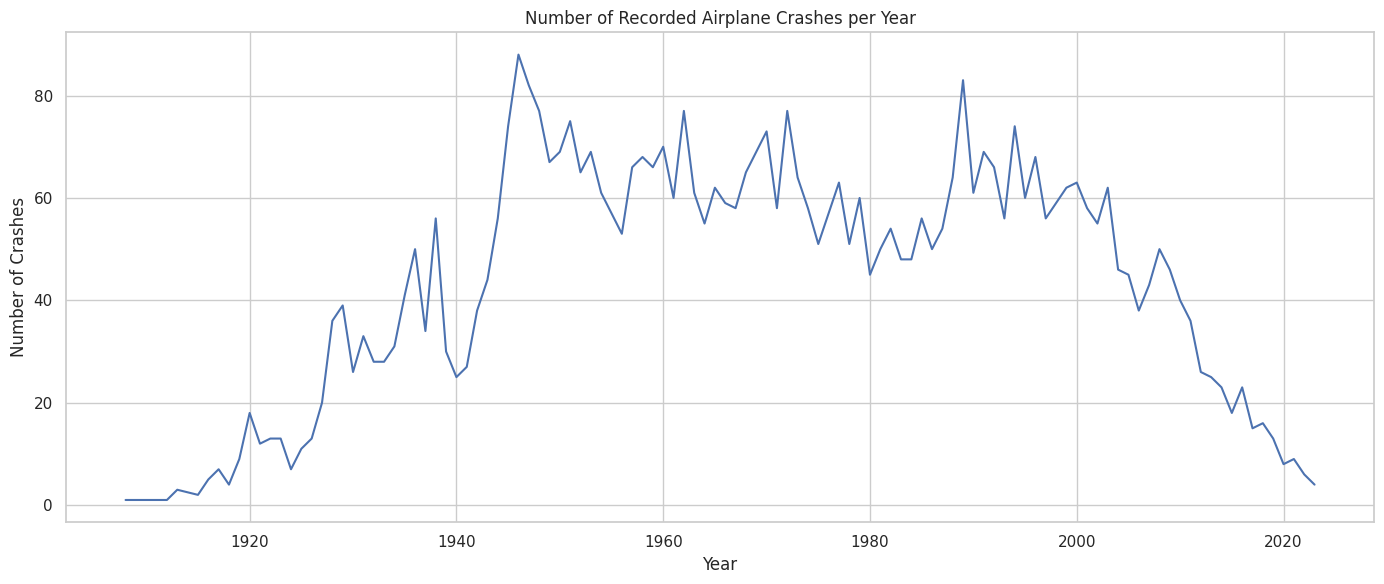

In [31]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=crashes_by_year,
    x="year",
    y="crashes"
)

plt.title("Number of Recorded Airplane Crashes per Year")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.tight_layout()
plt.show()

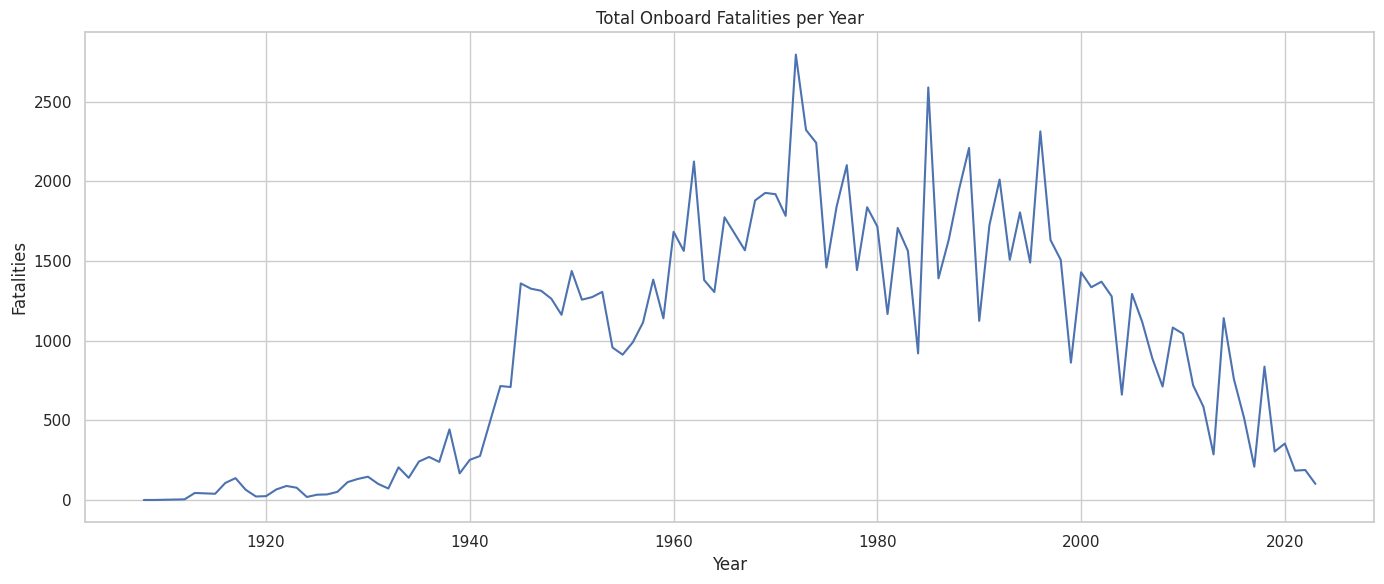

In [32]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=fatalities_by_year,
    x="year",
    y="fatalities"
)

plt.title("Total Onboard Fatalities per Year")
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.tight_layout()
plt.show()

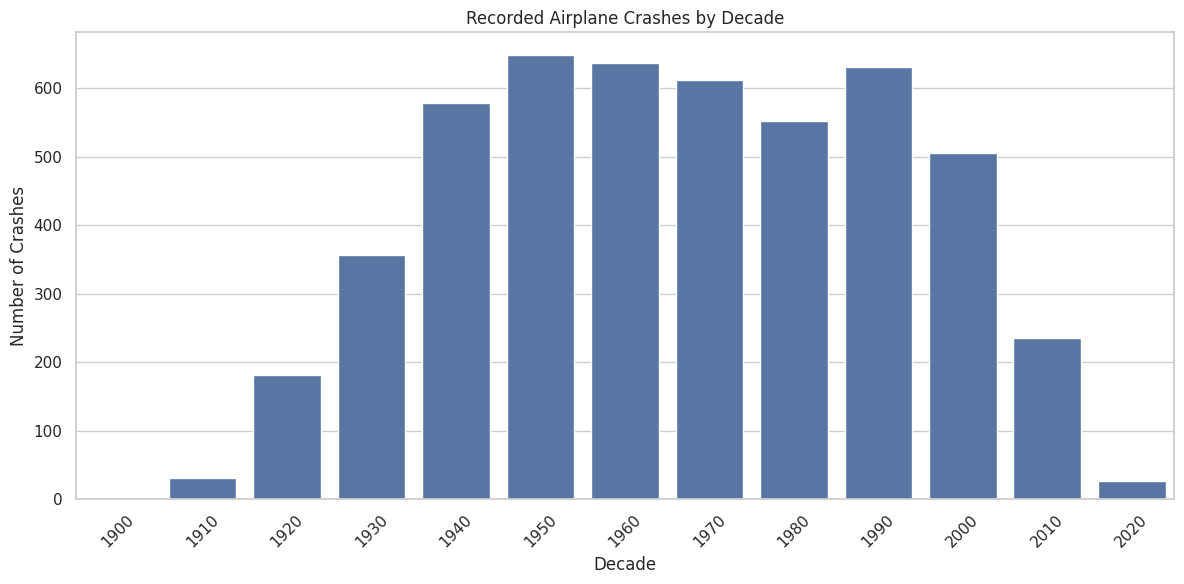

In [33]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=decade_summary,
    x="decade",
    y="crashes"
)

plt.title("Recorded Airplane Crashes by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

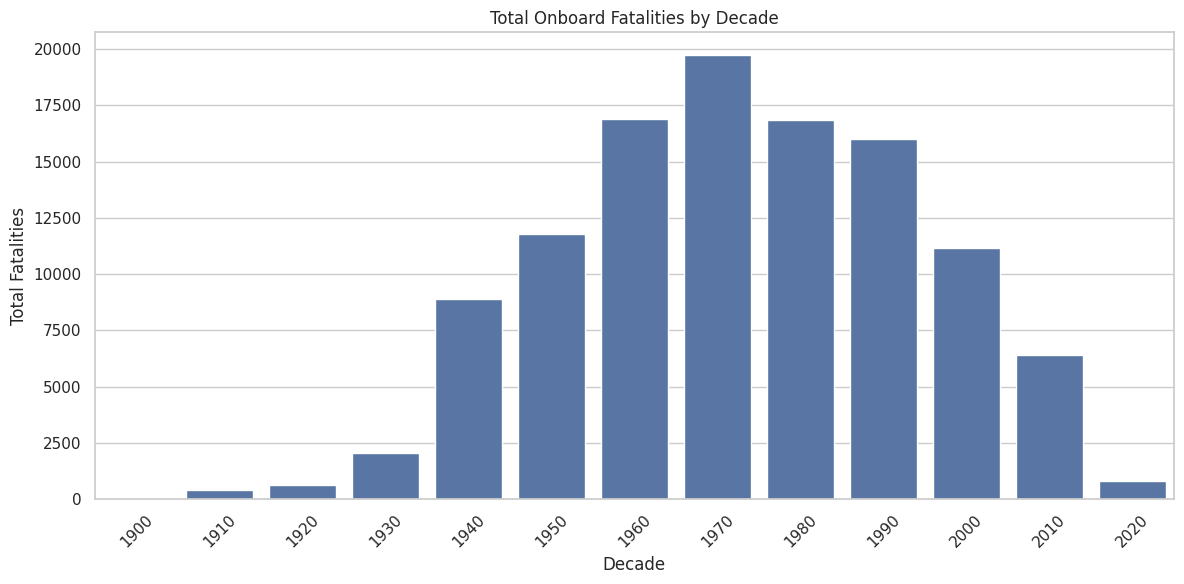

In [34]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=decade_summary,
    x="decade",
    y="total_fatalities"
)

plt.title("Total Onboard Fatalities by Decade")
plt.xlabel("Decade")
plt.ylabel("Total Fatalities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

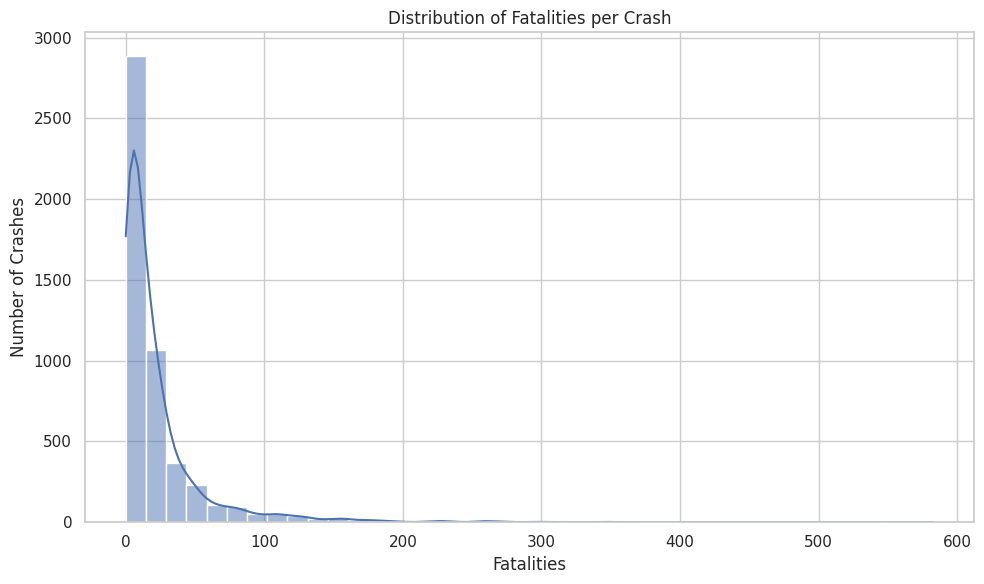

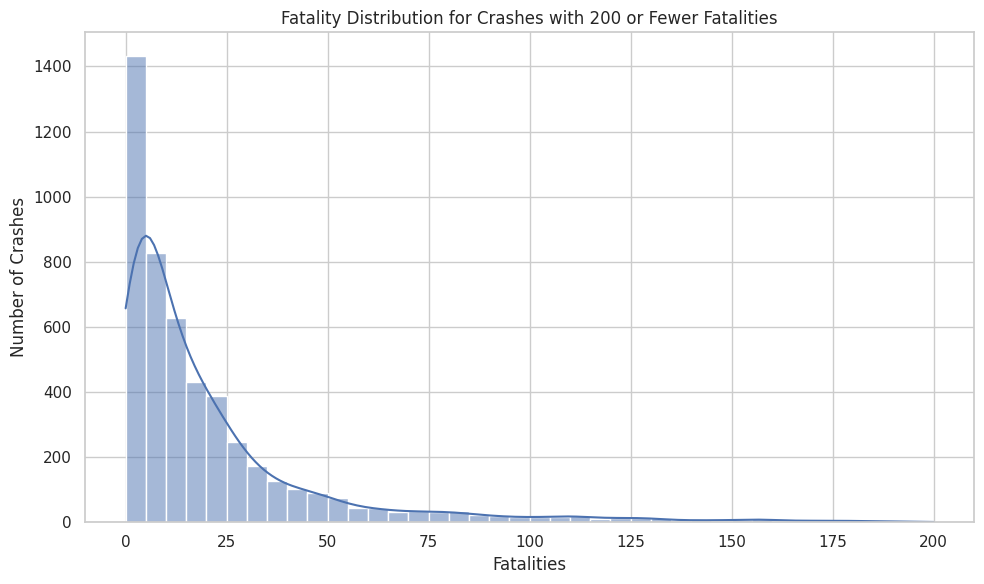

In [36]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="fatalities",
    bins=40,
    kde=True
)

plt.title("Distribution of Fatalities per Crash")
plt.xlabel("Fatalities")
plt.ylabel("Number of Crashes")
plt.tight_layout()
plt.show()

fatalities_under_200 = df[
    df["fatalities"].between(0, 200)
]

plt.figure(figsize=(10, 6))

sns.histplot(
    data=fatalities_under_200,
    x="fatalities",
    bins=40,
    kde=True
)

plt.title(
    "Fatality Distribution for Crashes with 200 or Fewer Fatalities"
)

plt.xlabel("Fatalities")
plt.ylabel("Number of Crashes")
plt.tight_layout()
plt.show()

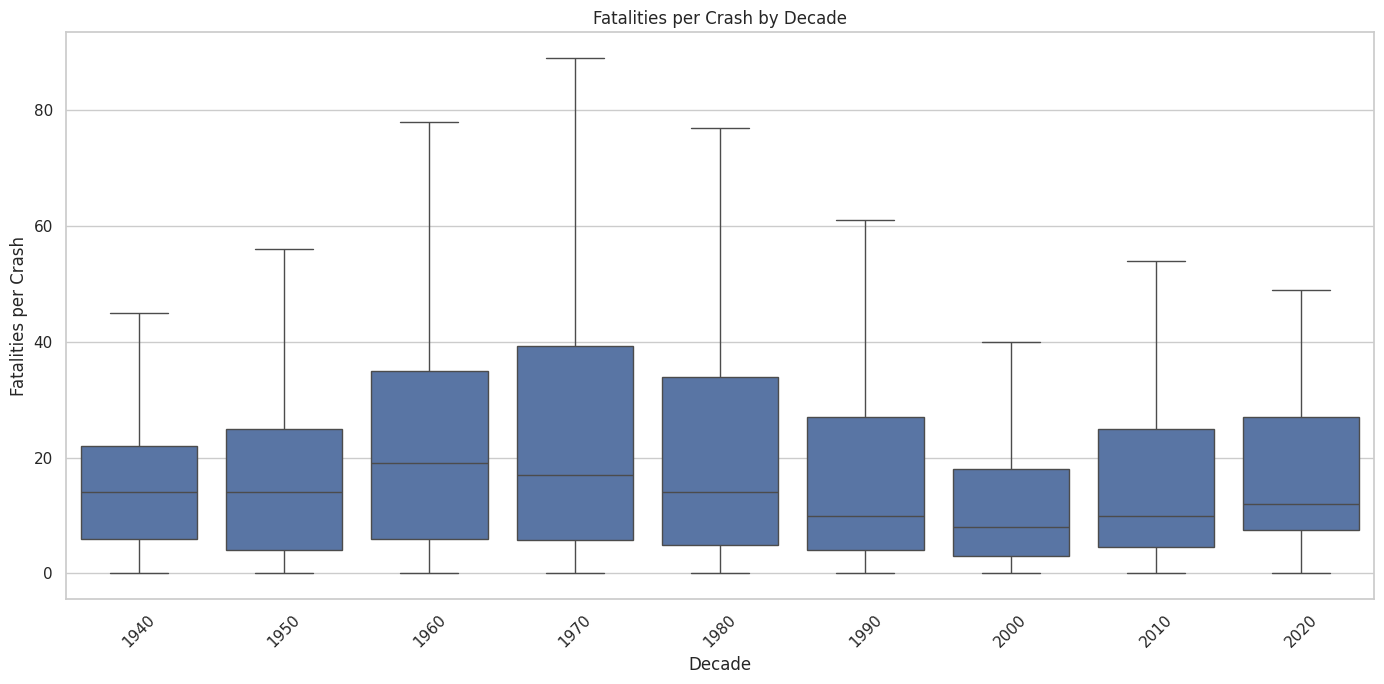

In [37]:
selected_decades = df[
    df["decade"].between(1940, 2020)
].copy()

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=selected_decades,
    x="decade",
    y="fatalities",
    showfliers=False
)

plt.title("Fatalities per Crash by Decade")
plt.xlabel("Decade")
plt.ylabel("Fatalities per Crash")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

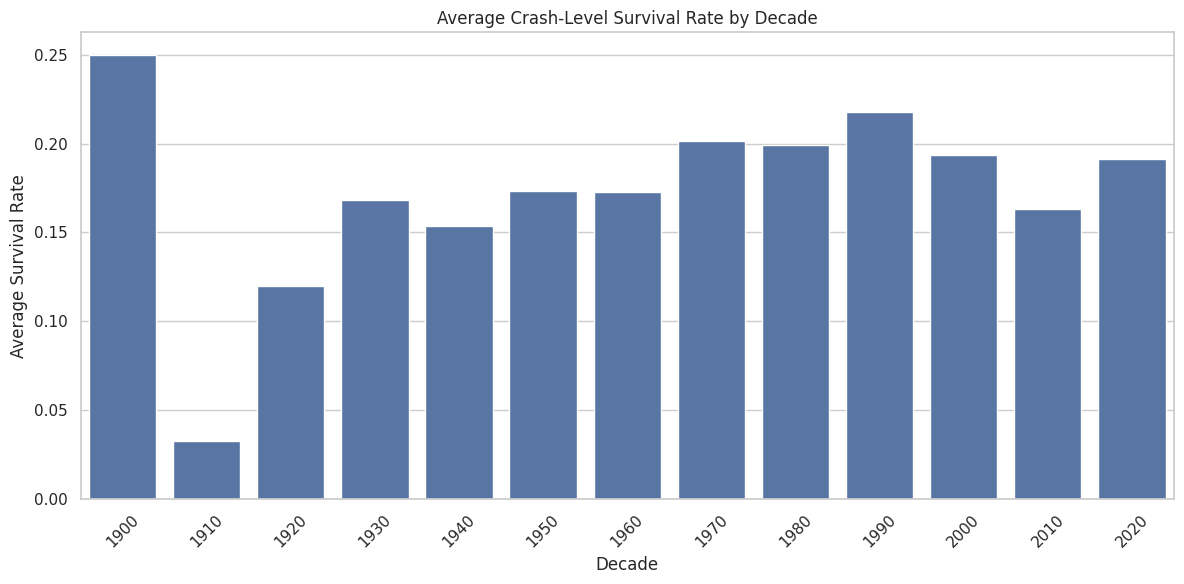

In [38]:
survival_by_decade = (
    df.dropna(
        subset=["decade", "survival_rate"]
    )
    .groupby("decade")["survival_rate"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=survival_by_decade,
    x="decade",
    y="survival_rate"
)

plt.title("Average Crash-Level Survival Rate by Decade")
plt.xlabel("Decade")
plt.ylabel("Average Survival Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

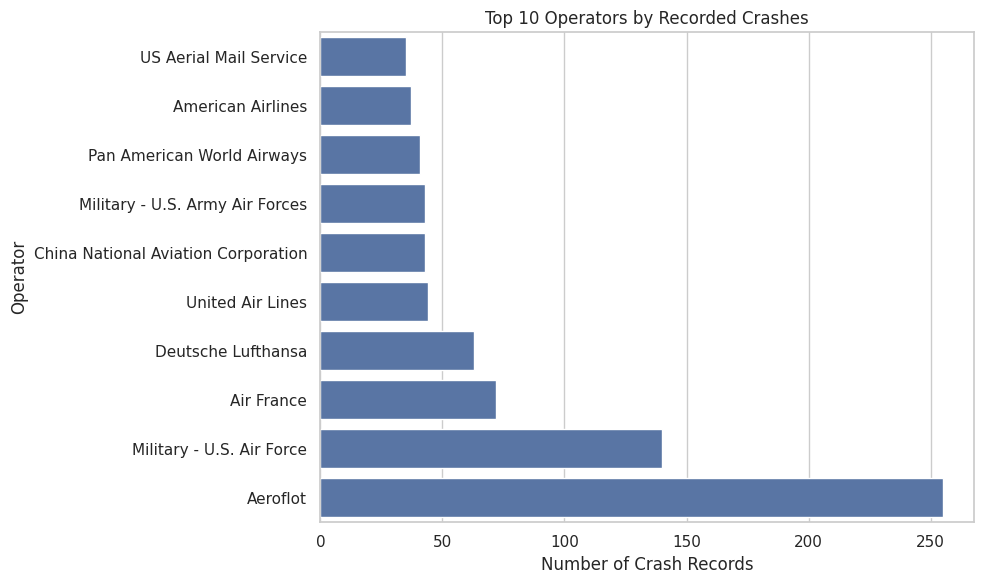

In [39]:
top_operators_df = (
    df["operator"]
    .value_counts()
    .head(10)
    .sort_values()
    .reset_index()
)

top_operators_df.columns = [
    "operator",
    "crashes"
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_operators_df,
    x="crashes",
    y="operator"
)

plt.title("Top 10 Operators by Recorded Crashes")
plt.xlabel("Number of Crash Records")
plt.ylabel("Operator")
plt.tight_layout()
plt.show()

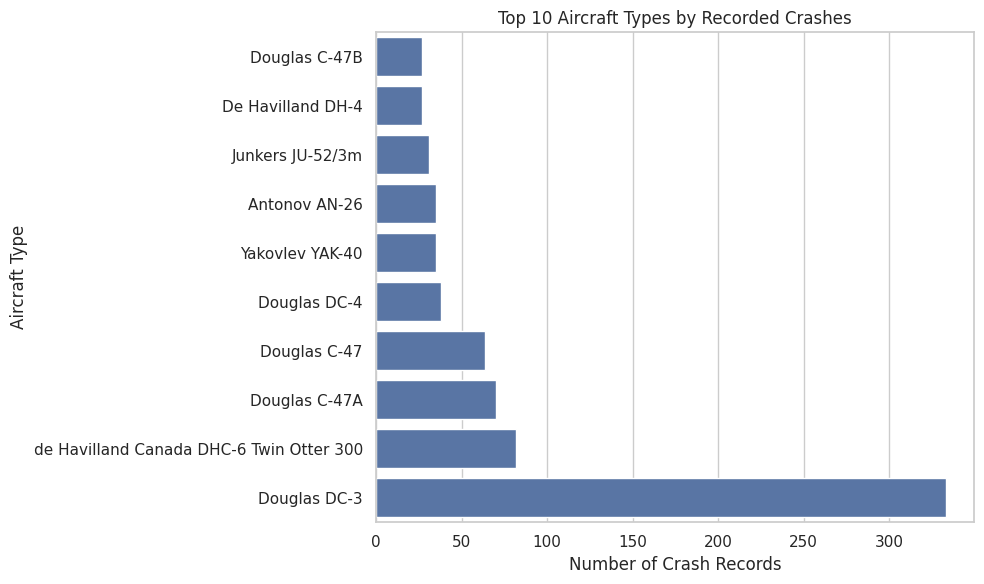

In [40]:
top_aircraft_df = (
    df["aircraft_type"]
    .value_counts()
    .head(10)
    .sort_values()
    .reset_index()
)

top_aircraft_df.columns = [
    "aircraft_type",
    "crashes"
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_aircraft_df,
    x="crashes",
    y="aircraft_type"
)

plt.title("Top 10 Aircraft Types by Recorded Crashes")
plt.xlabel("Number of Crash Records")
plt.ylabel("Aircraft Type")
plt.tight_layout()
plt.show()

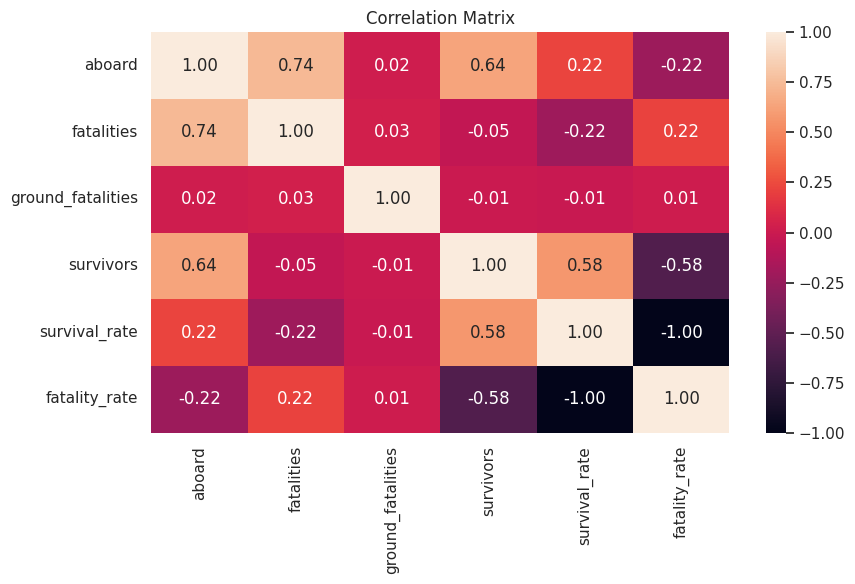

In [41]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

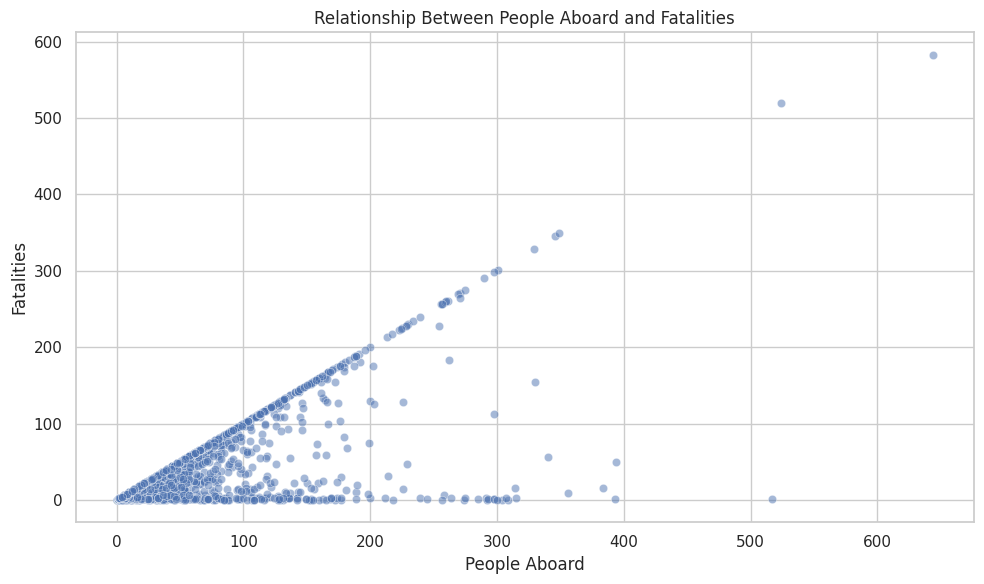

In [43]:
plot_data = df[
    ["aboard", "fatalities"]
].dropna()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_data,
    x="aboard",
    y="fatalities",
    alpha=0.5
)

plt.title("Relationship Between People Aboard and Fatalities")
plt.xlabel("People Aboard")
plt.ylabel("Fatalities")
plt.tight_layout()
plt.show()

Part 5: Final Insights and Report

In [45]:
decade_most_crashes = decade_summary.loc[
    decade_summary["crashes"].idxmax()
]

decade_most_fatalities = decade_summary.loc[
    decade_summary["total_fatalities"].idxmax()
]

year_most_crashes = crashes_by_year.loc[
    crashes_by_year["crashes"].idxmax()
]

year_most_fatalities = fatalities_by_year.loc[
    fatalities_by_year["fatalities"].idxmax()
]

print(
    "Decade with most recorded crashes:",
    int(decade_most_crashes["decade"])
)

print(
    "Number of crashes:",
    int(decade_most_crashes["crashes"])
)

print(
    "Decade with most fatalities:",
    int(decade_most_fatalities["decade"])
)

print(
    "Fatalities in that decade:",
    int(decade_most_fatalities["total_fatalities"])
)

print(
    "Year with most crashes:",
    int(year_most_crashes["year"])
)

print(
    "Crashes in that year:",
    int(year_most_crashes["crashes"])
)

print(
    "Year with most fatalities:",
    int(year_most_fatalities["year"])
)

print(
    "Fatalities in that year:",
    int(year_most_fatalities["fatalities"])
)

Decade with most recorded crashes: 1950
Number of crashes: 649
Decade with most fatalities: 1970
Fatalities in that decade: 19751
Year with most crashes: 1946
Crashes in that year: 88
Year with most fatalities: 1972
Fatalities in that year: 2796


Introduction

This project analyzed the Airplane Crashes and Fatalities dataset using Python. The analysis included data cleaning, exploratory analysis, statistical testing, and visualizations. Pandas was used to clean and summarize the data, NumPy was used for numerical calculations, SciPy was used for statistical testing, and Matplotlib and Seaborn were used to create graphs.

Data Cleaning

The dataset originally contained 4,998 crash records and 17 columns. The column names were standardized, and the date column was converted to datetime format. New columns were created for year, month, decade, survivors, survival rate, and fatality rate. Numerical columns were converted to numeric data types, missing values were identified, and duplicate records were checked.

Exploratory Analysis

The dataset contained a total of 4,990 recorded crashes. There were 111,644 onboard fatalities and 8,920 ground fatalities.

The average number of fatalities per crash was 22, while the median was 11. The difference between the mean and median suggests that a smaller number of highly fatal crashes increased the average.

The decade with the most recorded crashes was the 1950, while the year with the most recorded crashes was 1946.

Statistical Analysis

The fatality distribution had a skewness value of 4.61. This indicates that the distribution was right-skewed.

A Welch independent-samples t-test compared fatalities per crash in the 1980s and 2010s. The test produced a t-statistic of 0.89
and a P-value 0.37.

Because the P-value was above 0.05, the null hypothesis was not rejected. This means there was no statistically significant difference in average fatalities per crash between the two decades.

The Pearson correlation between the number of people aboard and fatalities was 0.74, indicating a strong positive relationship.

Main Insights

The fatality distribution was not even. Many crash records involved relatively small fatality totals, while a smaller number of major disasters involved extremely high fatality totals.

Crash counts and fatalities varied considerably across years and decades. The visualizations showed periods with much higher numbers of recorded crashes than others.

The number of people aboard was positively correlated with the number of fatalities. However, survival rates varied widely, showing that crashes involving similar numbers of people could have very different outcomes.

Operator and aircraft-type counts should be interpreted carefully. Operators or aircraft appearing more frequently in the dataset may simply have operated more flights or remained in service longer.

Limitations

The dataset contains records of crashes but does not include the total number of flights, passenger miles, or flights operated by each company. Therefore, it cannot be used to calculate the true accident rate or rank operators by safety.

Some fields contain missing information, and location names are not consistently formatted. Historical records may also be less complete than modern records.

Conclusion

This project demonstrated how Pandas, NumPy, SciPy, Matplotlib, and Seaborn can be combined to analyze a large historical dataset. The analysis identified patterns in crashes, fatalities, survival rates, and changes across decades.

Although the dataset provides valuable information about recorded aviation accidents, the findings describe patterns among crashes rather than the overall risk of air travel.